In [1]:
import pandas as pd
import numpy as np
import os
import cv2
from PIL import Image
from keras.preprocessing.image import load_img


2026-01-07 11:49:01.001563: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767786541.199609      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767786541.254713      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767786541.702267      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767786541.702301      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767786541.702304      24 computation_placer.cc:177] computation placer alr

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, Conv2D, MaxPooling2D,
    InputLayer, BatchNormalization, Add, GlobalMaxPooling2D
)
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.initializers import RandomUniform, GlorotUniform, Constant, Identity

from sklearn.model_selection import train_test_split
from pathlib import Path


In [3]:
base_dirs = [r'/kaggle/input/utkface-new/UTKFace']

In [4]:
image_paths = []
age_labels = []
gender_paths = []


In [5]:
from tqdm import tqdm


In [6]:
for base_dir in base_dirs:
    for filename in tqdm(os.listdir(base_dir)):
        temp = filename.split('_')
        if temp[0].isdigit():
            age = int(temp[0])
            gender = int(temp[1])
            image_path = os.path.join(base_dir,filename)
            image_paths.append(image_path)
            age_labels.append(age)
            gender_paths.append(gender)

100%|██████████| 23708/23708 [00:00<00:00, 558361.27it/s]


In [7]:
df = pd.DataFrame()
df['image'],df['age'],df['gender'] = image_paths,age_labels,gender_paths
df.head()

,image,age,gender
0,/kaggle/input/utkface-new/UTKFace/26_0_2_20170...,26,0
1,/kaggle/input/utkface-new/UTKFace/22_1_1_20170...,22,1
2,/kaggle/input/utkface-new/UTKFace/21_1_3_20170...,21,1
3,/kaggle/input/utkface-new/UTKFace/28_0_0_20170...,28,0
4,/kaggle/input/utkface-new/UTKFace/17_1_4_20170...,17,1


In [8]:
print(f"Dataframe:{df}")
print(f"Dataframe shape:{df.shape}")
print(f"first few rows of the Dataframe:{df.head()}")

Dataframe:                                                   image  age  gender
0      /kaggle/input/utkface-new/UTKFace/26_0_2_20170...   26       0
1      /kaggle/input/utkface-new/UTKFace/22_1_1_20170...   22       1
2      /kaggle/input/utkface-new/UTKFace/21_1_3_20170...   21       1
3      /kaggle/input/utkface-new/UTKFace/28_0_0_20170...   28       0
4      /kaggle/input/utkface-new/UTKFace/17_1_4_20170...   17       1
...                                                  ...  ...     ...
23703  /kaggle/input/utkface-new/UTKFace/41_0_0_20170...   41       0
23704  /kaggle/input/utkface-new/UTKFace/42_0_0_20170...   42       0
23705  /kaggle/input/utkface-new/UTKFace/2_0_2_201612...    2       0
23706  /kaggle/input/utkface-new/UTKFace/65_1_0_20170...   65       1
23707  /kaggle/input/utkface-new/UTKFace/66_0_1_20170...   66       0

[23708 rows x 3 columns]
Dataframe shape:(23708, 3)
first few rows of the Dataframe:                                               image  age  gender

In [9]:
gender_dict = {0:"Male",1:"Female"}

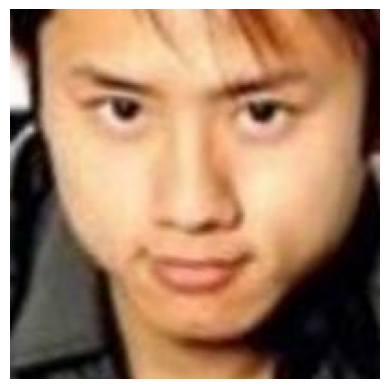

In [10]:
if not df.empty:
    try:
        img = Image.open(df['image'][0])
        plt.axis('off')
        plt.imshow(img)
        plt.show()
    except Exception as e:
        print(f'error opening image:{e}')
else:
    print(f"Dataframe is empty, No images found.")
        

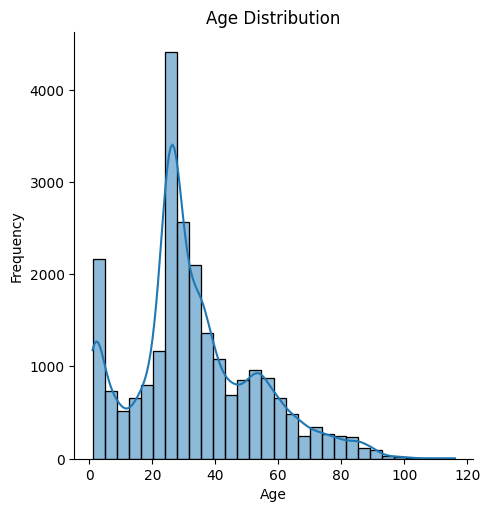

In [11]:
sns.displot(df['age'],kde = True,bins = 30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [12]:
from PIL import Image
import numpy as np
from tqdm import tqdm

def extract_feature(images):
    features = []
    
    for img_path in tqdm(images):
        img = Image.open(img_path).convert('L')     # FIXED
        img = img.resize((128, 128), Image.BILINEAR)
        img = np.array(img)
        features.append(img)

    features = np.array(features)
    features = features.reshape(len(features), 128, 128, 1)
    return features


In [13]:
x = extract_feature(df['image'])
print(f"X_shape:\t{x.shape}")


100%|██████████| 23708/23708 [02:12<00:00, 178.43it/s]


X_shape:	(23708, 128, 128, 1)


In [14]:
x = x/255.0
y_gender = np.array(df['gender'])
y_age = np.array(df['age'])
print("shape of y_gender:",y_gender.shape)
print("shape of y_age:",y_age.shape)

shape of y_gender: (23708,)
shape of y_age: (23708,)


In [15]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model

input_shape = (128, 128, 1)

inputs = Input(shape=input_shape)

conv1 = Conv2D(32, (3,3), activation='relu')(inputs)
maxp1 = MaxPooling2D((2,2))(conv1)

conv2 = Conv2D(64, (3,3), activation='relu')(maxp1)
maxp2 = MaxPooling2D((2,2))(conv2)

conv3 = Conv2D(128, (3,3), activation='relu')(maxp2)
maxp3 = MaxPooling2D((2,2))(conv3)

conv4 = Conv2D(256, (3,3), activation='relu')(maxp3)
maxp4 = MaxPooling2D((2,2))(conv4)

flatten = Flatten()(maxp4)

dense1 = Dense(256, activation='relu')(flatten)   # for gender
dense2 = Dense(256, activation='relu')(flatten)   # for age

dropout1 = Dropout(0.3)(dense1)
dropout2 = Dropout(0.3)(dense2)

output1 = Dense(1, activation='sigmoid', name='gender_out')(dropout1)
output2 = Dense(1, activation='linear', name='age_out')(dropout2)

model = Model(inputs=inputs, outputs=[output1, output2])
model.summary()


I0000 00:00:1767786690.434057      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767786690.437876      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 126, 126,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 63, 63,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 61, 61,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 30, 30,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 12, 12,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 6, 6, 256) │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 9216)      │          0 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  2,359,552 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │  2,359,552 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_out (Dense)  │ (None, 1)         │        257 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_out (Dense)     │ (None, 1)         │        257 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,107,458 (19.48 MB)

 Trainable params: 5,107,458 (19.48 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
y_combined = np.column_stack((y_gender,y_age))
X_train,X_temp,y_combined_train,y_combined_temp = train_test_split(x,y_combined,test_size = 0.2,random_state = 42)
x_test,x_val,y_combined_test,y_combined_val = train_test_split(X_temp,y_combined_temp,test_size = 0.5,random_state = 42)

In [17]:
y_train_gender,y_train_age = y_combined_train[:,0],y_combined_train[:,1]
y_test_gender,y_test_age = y_combined_test[:,0],y_combined_test[:,1]
y_val_gender,y_val_age = y_combined_val[:,0],y_combined_val[:,1]


In [18]:
model_path = './best_model.keras'
checkpointer = ModelCheckpoint(filepath = model_path,monitor = 'val_gender_out_accuracy',verbose = 1,save_best_only = True,mode = 'max')



In [19]:
from tensorflow.keras.callbacks import LearningRateScheduler

model.compile(
    loss=['binary_crossentropy', 'mae'],
    optimizer='adam',
    metrics=['accuracy', 'mae']
)

annealer = LearningRateScheduler(lambda epoch: 1e-3 * 0.9 ** epoch)


In [20]:
total_images = len(image_paths)
print(f"total number of images: {total_images}")


total number of images: 23708


In [21]:
train_images = len(X_train)
validation_images = len(x_val)
test_images = len(x_test)
print(f"Number of the training images:{train_images}")
print(f"Number of the validation images:{validation_images}")
print(f"Number of the test images:{test_images}")


Number of the training images:18966
Number of the validation images:2371
Number of the test images:2371


In [22]:
import tensorflow as tf
tf.config.run_functions_eagerly(True)


In [23]:
history = model.fit(
    x = X_train,
    y = [y_train_gender,y_train_age],
    batch_size = 128,
    epochs = 100,
    validation_data = (x_val,[y_val_gender,y_val_age]),
    callbacks = [annealer, checkpointer]
)

Epoch 1/100


I0000 00:00:1767786697.048997      24 cuda_dnn.cc:529] Loaded cuDNN version 91002


149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - age_out_loss: 18.9251 - age_out_mae: 18.9251 - gender_out_accuracy: 0.5345 - gender_out_loss: 0.7319 - loss: 19.6570
Epoch 1: val_gender_out_accuracy improved from -inf to 0.47027, saving model to ./best_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 27s 156ms/step - age_out_loss: 18.9092 - age_out_mae: 18.9092 - gender_out_accuracy: 0.5345 - gender_out_loss: 0.7316 - loss: 19.6409 - val_age_out_loss: 14.9399 - val_age_out_mae: 14.9399 - val_gender_out_accuracy: 0.4703 - val_gender_out_loss: 0.6941 - val_loss: 15.6341 - learning_rate: 0.0010
Epoch 2/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - age_out_loss: 14.5471 - age_out_mae: 14.5471 - gender_out_accuracy: 0.5765 - gender_out_loss: 0.6702 - loss: 15.2173
Epoch 2: val_gender_out_accuracy improved from 0.47027 to 0.71742, saving model to ./best_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 22s 150ms/step - age_out_loss: 14.5448 - age_out_mae: 14.5448 - gender_out_accuracy: 0.5769 - gender_out_los

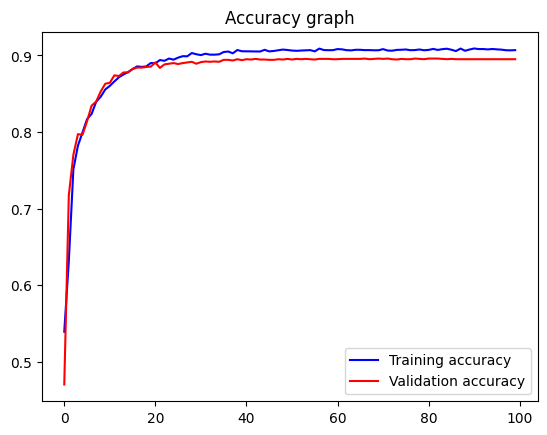

In [24]:
acc = history.history['gender_out_accuracy']
val_acc = history.history['val_gender_out_accuracy']
epochs = range(len(acc))
plt.plot(epochs,acc,'b',label = 'Training accuracy')
plt.plot(epochs,val_acc,'r',label='Validation accuracy')
plt.title('Accuracy graph')
plt.legend()
plt.show()

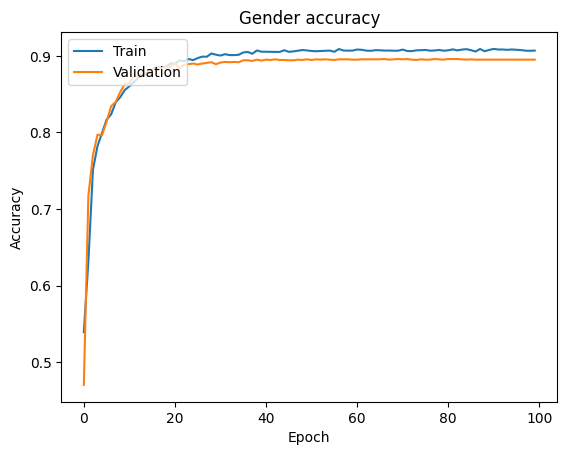

In [25]:
plt.plot(history.history['gender_out_accuracy'])
plt.plot(history.history['val_gender_out_accuracy'])
plt.title('Gender accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'],loc='upper left')
plt.show()

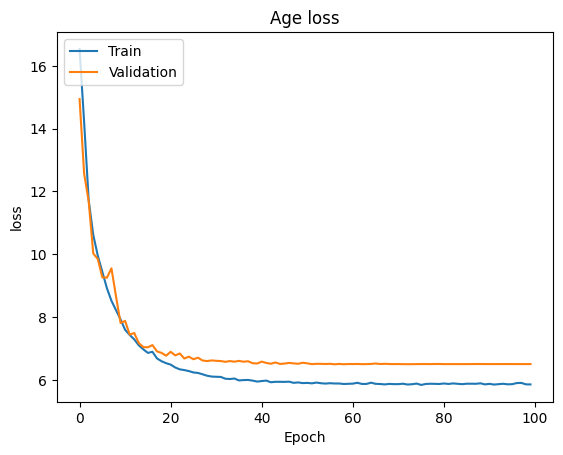

In [26]:
plt.plot(history.history['age_out_mae'])
plt.plot(history.history['val_age_out_mae'])
plt.title('Age loss')
plt.ylabel('loss')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'],loc='upper left')
plt.show()

In [27]:
image_index = 3000
print(f"original gender:\t{gender_dict[y_gender[image_index]]}\t original age:\t{y_age[image_index]}")

original gender:	Male	 original age:	28
